# Deteksi Intrusi Jaringan - NSL-KDD

Notebook ini membangun model klasifikasi multi-kelas untuk mendeteksi serangan jaringan menggunakan dataset **NSL-KDD** (versi `KDDTrain+.txt`, 41 fitur + label + skor difficulty).

**Konteks dataset (hasil pengecekan aktual):**
- Jumlah baris: **125.973**, jumlah kolom: **43** (41 fitur + `label` + `difficulty`).
- Tidak ada *missing value* dan tidak ada baris duplikat — data relatif bersih untuk langsung diproses.

**Tujuan akhir:** membandingkan 3 algoritma (Decision Tree, Random Forest, Gradient Boosting), memilih yang terbaik berdasarkan *recall* makro, lalu menyimpan model untuk dipakai ulang.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score
import joblib


## 1. Load Data

In [3]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations','num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count',
    'serror_rate', 'srv_serror_rate', 'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

df = pd.read_csv('data/KDDTrain+.txt', names=columns)
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

## 2. Cek Missing Value, Duplikat, dan Pemetaan Kategori Serangan

In [4]:
missing_value = df.isnull().sum()
duplicate_value = df.duplicated().sum()
print(f'\nNilai Kosong : \n{missing_value}')
print(f'Nilai Duplikat : {duplicate_value}\n')

df = df.drop(columns=['difficulty'])

attack_mapping = {
    'normal' : 'normal',
    # DoS - Denial of Service
    'back' : 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf' : 'DoS', 'teardrop': 'DoS',
    # Probe - Surveillance/scanning
    'satan' : 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    # R2L - Remote to Local
    'guess_passwd' : 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L',
    'multihop' : 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L', 'spy': 'R2L',
    # U2R - User to Root
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'rootkit': 'U2R', 'perl': 'U2R',
}

df['attack_category'] = df['label'].map(attack_mapping)
df = df.drop(columns=['label'])



Nilai Kosong : 
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate             

### Visualisasi Distribusi Serangan

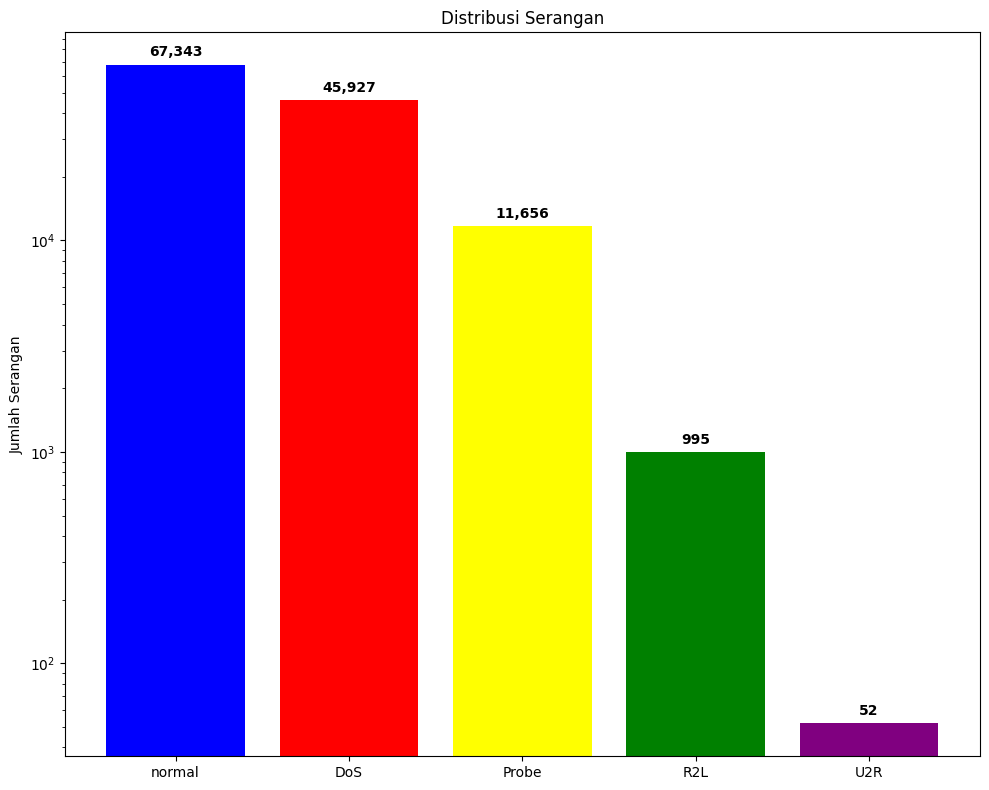

In [5]:
plt.figure(figsize=(10, 8))
orders = ['normal', 'DoS', 'Probe', 'R2L', 'U2R']
colors = ['blue', 'red', 'yellow','green', 'purple']
counts = df['attack_category'].value_counts().reindex(orders)

bars = plt.bar(counts.index, counts.values, color=colors)
plt.yscale('log')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold')
plt.title('Distribusi Serangan')
plt.ylabel('Jumlah Serangan')
plt.tight_layout()
plt.savefig('Distribusi Label.png', dpi=100)
plt.show()



## 3. Memisahkan Target dan Praproses Fitur

In [6]:
X = df.drop(columns=['attack_category'])
y = df['attack_category']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

nominal_cols = ['protocol_type', 'service', 'flag']
numeric_cols = [a for a in X.columns if a not in nominal_cols]

preprocessor = make_column_transformer(
    (OneHotEncoder(drop='first'), nominal_cols),
    ('passthrough', numeric_cols)
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'Jumlah data latih : {len(X_train)}')
print(f'Jumlah data test : {len(X_test)}\n')


Jumlah data latih : 100778
Jumlah data test : 25195




## 4. Melatih dan Membandingkan Model

In [7]:
daftar_model = {
    'DecisionTree' : DecisionTreeClassifier(random_state=42),
    'RandomForest' : RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'GradientBoosting' : GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42),
}

hasil = {}
print('========== Perbandingan Model ==========')

for name, clf in daftar_model.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    acc = (pred == y_test). mean()
    f1 = f1_score(y_test, pred, average='macro')
    recall = recall_score(y_test, pred, average='macro')
    hasil[name] = {'accuracy': acc, 'f1': f1, 'recall': recall, 'pipeline': pipe, 'pred': pred}
    print(f'{name} | Accuracy = {acc:.3f} | F1-Score = {f1:.3f} | Recall Score = {recall:.3f}')

model_terbaik = max(hasil, key=lambda k:hasil[k]['recall'])
print(f'\nModel Terbaik berdasarkan Recall macro adalah {model_terbaik}')


========== Perbandingan Model ==========
DecisionTree | Accuracy = 0.998 | F1-Score = 0.928 | Recall Score = 0.953
RandomForest | Accuracy = 0.999 | F1-Score = 0.974 | Recall Score = 0.971
GradientBoosting | Accuracy = 0.997 | F1-Score = 0.881 | Recall Score = 0.858

Model Terbaik berdasarkan Recall macro adalah RandomForest



## 5. Confusion Matrix

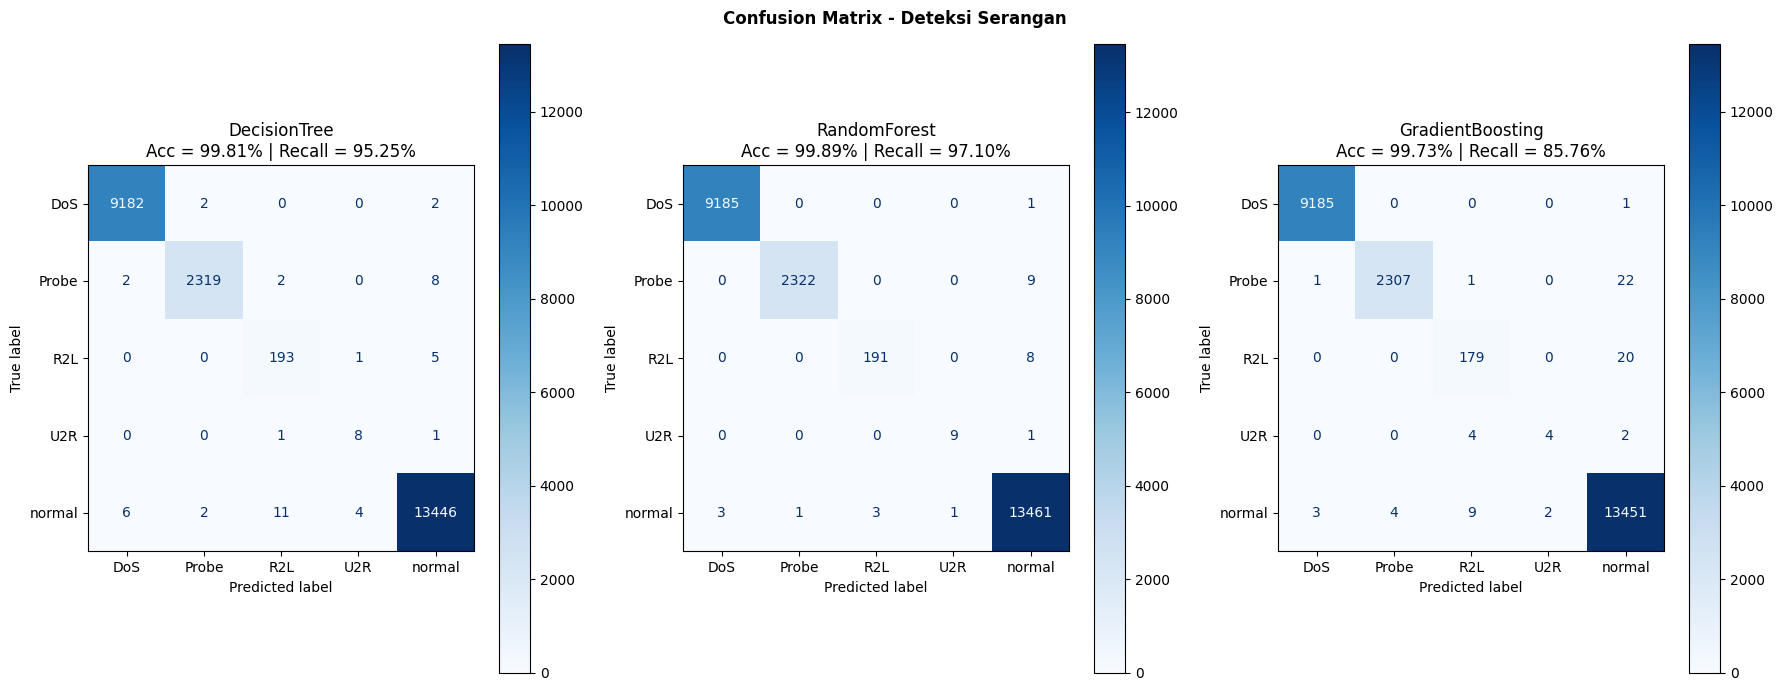

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for i, (name, data) in enumerate(hasil.items()):
    cm = confusion_matrix(y_test, data['pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=True)
    axes[i].set_title(f'{name}\nAcc = {data["accuracy"]:.2%} | Recall = {data["recall"]:.2%}')
    axes[i].tick_params(axis='x')
plt.suptitle('Confusion Matrix - Deteksi Serangan', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('Confusion Matrix.png', dpi=100)
plt.show()



## 6. Feature Importance

C:\Users\THINKPAD\AppData\Local\Temp\ipykernel_18228\650997920.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='kepentingan', y='fitur', palette='viridis')


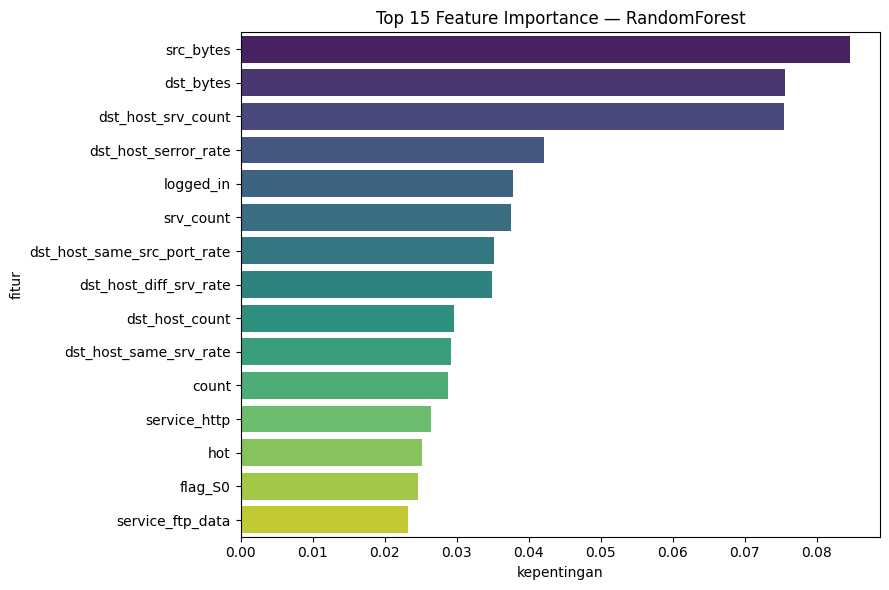

In [9]:
try: 
    clf_step = hasil[model_terbaik]['pipeline'].named_steps['classifier']
    pred_step = hasil[model_terbaik]['pipeline'].named_steps['preprocessor']
    ohe_names = list(pred_step.named_transformers_['onehotencoder'].get_feature_names_out(nominal_cols))
    semua_fitur = ohe_names + numeric_cols

    fi_df = (pd.DataFrame({'fitur': semua_fitur, 'kepentingan': clf_step.feature_importances_}).
             sort_values('kepentingan', ascending=False).head(15))
    plt.figure(figsize=(9, 6))
    sns.barplot(data=fi_df, x='kepentingan', y='fitur', palette='viridis')
    plt.title(f'Top 15 Feature Importance — {model_terbaik}')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100)
    plt.show()
except AttributeError:
    print(f'(Feature importance tidak tersedia untuk {model_terbaik})')



## 7. Simpan Model

In [10]:
joblib.dump({'pipeline': hasil[model_terbaik]['pipeline'], 'label_encoder':le}, 'model_nsl.pkl')

['model_nsl.pkl']

## Ringkasan

- **Model terpilih:** Random Forest (recall macro 0,971), karena paling seimbang dalam mengenali kelas minoritas tanpa mengorbankan akurasi keseluruhan.